Restarted hazGAN (Python 3.14.2)

In [ ]:
"""
Plots mangrove damages and compares 1-in-10 year events.

1. Multiplies the damage probability with the mangrove area in each grid cell to get expected damage area.
2. Assign return periods based on expected mangrove damage.
3. Plot risk profile and damage probability fields.
"""
# %%
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
from environs import Env
import matplotlib.pyplot as plt
from pathlib import Path

from utils.statistics import calculate_total_return_periods

bay_of_bengal_crs = 24346
savefigs = False
FRACTION = False  # whether to divide by mangrove area

env = Env()
env.read_env()

True

In [ ]:
samples_dir    = Path(env.str("SAMPLES_DIR"))
mangroves_dir  = Path(env.str("MANGROVE_DIR"))
mangroves_path = Path(env.str("MANGROVES"))
figdir = Path(env.str("FIG_DIR")) / "mangroves"
figdir.mkdir(parents=True, exist_ok=True)

train_damages       = xr.open_dataset(mangroves_dir / "results" / "train_damages.nc")
fake_damages        = xr.open_dataset(mangroves_dir / "results" / "fake_damages.nc")
independent_damages = xr.open_dataset(mangroves_dir / "results" / "independent_damages.nc")
dependent_damages   = xr.open_dataset(mangroves_dir / "results" / "dependent_damages.nc")

# different rates for different datasets
rate = train_damages.sizes["sample"] / 81
train_damages['rate']       = rate
fake_damages['rate']        = rate
independent_damages['rate'] = 1249 / 81

In [ ]:
mangrove_grid_path = mangroves_dir / "mangrove_grid.nc"

if not os.path.exists(mangrove_grid_path):
    from shapely.geometry import box
    from utils import mangroveDamageModel

    #  Step 1: Clip mangroves to bay of bengal
    aoi = box(80.0, 10.0, 95.0, 25.0)  # Bay of Bengal bounding box
    mangroves = gpd.read_file(mangroves_path, mask=aoi)
    mangroves = mangroves.set_crs(epsg=4326).drop(columns='PXLVAL')
    mangroves['area']  = mangroves.to_crs(bay_of_bengal_crs).area

    # Step 2: Project mangroves to grid
    model = mangroveDamageModel()
    mangrove_grid = model.intersect_mangroves_with_grid(mangroves, train_damages.isel(sample=0))
    mangrove_grid.to_netcdf(mangrove_grid_path)

mangrove_grid = xr.open_dataset(mangrove_grid_path)
mangrove_area = mangrove_grid["area"].sum().values.item()
print(f"Total mangrove area: {mangrove_area:.2f} km²")

Total mangrove area: 9917.85 km²


In [ ]:
train_damages['expected_damage']       = train_damages['damage_prob'] * mangrove_grid['area']
fake_damages['expected_damage']        = fake_damages['damage_prob'] * mangrove_grid['area']
independent_damages['expected_damage'] = independent_damages['damage_prob'] * mangrove_grid['area']
dependent_damages['expected_damage']   = dependent_damages['damage_prob'] * mangrove_grid['area']

In [ ]:
tree = xr.DataTree()
tree['ERA5'] = xr.DataTree(train_damages)
tree['HazGAN']  = xr.DataTree(fake_damages)
tree['Independent'] = xr.DataTree(independent_damages)
tree['Dependent'] = xr.DataTree(dependent_damages)
tree.to_netcdf(mangroves_dir / "results" / "damage_areas.nc")

In [ ]:
def calculate_total_return_periods(
        damages:xr.Dataset, var:str,
        fraction:bool=FRACTION,
        rate:float=rate,
        ) -> xr.Dataset:
    """
    Calculate total damages and return periods for a given variable
    in the damages dataset.
    """
    # skip root node in datatree
    if len(damages.data_vars) > 0:
        # aggregate to overall damages
        npy = rate# damages['rate'].values.item()
        totals = damages[var].sum(dim=['lat', 'lon']).to_dataset()

        if fraction:
            totals = totals / mangrove_area
        
        # calculate return periods
        N = totals[var].sizes['sample']
        rank = totals[var].rank(dim='sample')
        totals['exceedence_prob'] = 1 - rank / (1 + N)
        totals['return_period'] = 1 / (npy * totals['exceedence_prob'])
        totals = totals.sortby('return_period')
        return totals

tree = tree.map_over_datasets(calculate_total_return_periods, 'expected_damage')

# calculate return periods differently for dependent damages
tree['Dependent'] = dependent_damages
tree['Dependent']['expected_damage'] = tree['Dependent']['expected_damage'].sum(dim=['lat', 'lon'])
if FRACTION:
    tree['Dependent']['expected_damage'] =  tree['Dependent']['expected_damage'] / mangrove_area

In [ ]:
xmin = min([ds['return_period'].min() for ds in tree.values()]).data.item()
xmax = max([ds['return_period'].max() for ds in tree.values()]).data.item()
ymin = min([ds['expected_damage'].min() for ds in tree.values()]).data.item()
ymax = max([ds['expected_damage'].max() for ds in tree.values()]).data.item()

(81,)
(494,)
(4101,)
(9,)


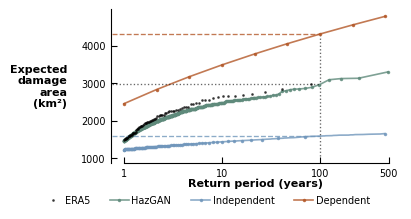

In [ ]:
def riskprofileplot(tree:xr.DataTree, label:str, ax:plt.Axes,
                    minrp:float=1, maxrp:float=500, **kwargs):
    ds = tree[label].to_dataset()
    ds = ds.where(ds['return_period'] >= minrp, drop=True)
    ds = ds.where(ds['return_period'] <= maxrp, drop=True)
    print(ds["expected_damage"].shape)
    ax.plot(ds['return_period'], ds['expected_damage'], label=label, **kwargs)

plt.rcParams.update({
    'font.size': 7,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'figure.titlesize': 8,
    'figure.titleweight': 'bold',
    'axes.titleweight': 'normal',
    'legend.fontsize': 7,
    'legend.frameon': False,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': True,
    'axes.spines.bottom': True
})

c0, c1, c2, c3 ='#4D4D4D', '#7096BB','#5F8A7B', '#B35828'
lw = 1.2
scatter_kwargs = {'linestyle': 'none', 'marker': 'o', 'mfc': 'k',
                  'mec': 'k', 'mew': 0.25, 'alpha': 0.8, 'ms': 1.5}
line_kwargs = {'linewidth': lw, 'alpha': 0.8, 'marker': 'o', 'ms': 1.5} #, 'mfc': 'none'

fig, ax = plt.subplots(figsize=(3.75, 2))

riskprofileplot(tree, 'ERA5', ax, color='k', **scatter_kwargs, zorder=10)
riskprofileplot(tree, 'HazGAN', ax, color=c2, **line_kwargs, markevery=1)
riskprofileplot(tree, 'Independent', ax, color=c1, zorder=0, **line_kwargs, markevery=50)
riskprofileplot(tree, 'Dependent', ax, color=c3, **line_kwargs)

def rp_damages(tree:xr.DataTree, label:str, rp:float) -> xr.Dataset:
    ds = tree[label].to_dataset()
    ds = ds.swap_dims({'sample': 'return_period'})
    damages = ds.sel(return_period=rp, method='nearest')["expected_damage"]
    return damages.values.item()


ax.vlines(100, ax.get_ylim()[0], rp_damages(tree, 'Dependent', 100), color='k', linestyle=":", alpha=0.6, linewidth=0.8 * lw, zorder=1)
ax.hlines(rp_damages(tree, 'ERA5', 100), 0, 100, color='k', linestyle=":", alpha=0.6, linewidth=0.8 * lw)
# ax.hlines(rp_damages(tree, 'HazGAN', 100),0, 100, color=c2, linestyle="--", alpha=0.8, linewidth=0.8 * lw)
ax.hlines(rp_damages(tree, 'Independent', 100),0, 100, color=c1, linestyle="--", alpha=0.8, linewidth=0.8 * lw)
ax.hlines(rp_damages(tree, 'Dependent', 100),0, 100, color=c3, linestyle="--", alpha=0.8, linewidth=0.8 * lw)

# legend options
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.33, -0.15),  # Center horizontally, below the plot
    ncol=4,  # Spread entries horizontally
    frameon=False,
    handletextpad=0.25,  # Reduce space between handle and text (default is 0.8)
    columnspacing=2.0,  # Reduce space between columns (default is 2.0)
    labelspacing=0.4
)
plt.setp(ax.get_legend().get_title(), fontsize='12', fontweight='bold')

# configure x-axis
ax.set_xscale('log')
yticks = np.array([ymin, 2000, 4000, 6000, ymax])
yticks = yticks[(yticks > ymin) & (yticks <= ymax)]
yticklabels = [f"{y:.0f}" for y in yticks]

ax.set_xticks([1, 10, 100, 500], labels=['1', '10', '100', '500'])
ax.spines['bottom'].set_bounds(1, 500)

# ticks config
ax.tick_params(direction='in')
ax.xaxis.set_tick_params(which='minor', direction='in')
ax.yaxis.set_tick_params(which='minor', direction='in')
ax.tick_params(axis='x', length=4)
ax.tick_params(axis='y', length=4)
ax.tick_params(axis='x', which='minor', length=2)
ax.tick_params(axis='y', which='minor', length=2)

# turn off minor x-ticks
ax.xaxis.set_minor_formatter(plt.NullFormatter())
ax.xaxis.set_minor_locator(plt.NullLocator())

ax.set_xlabel("Return period (years)", fontweight='bold', labelpad=0)
ax.set_ylabel("Expected\ndamage\narea\n(km²)", 
              fontweight='bold',
              rotation=0,
              labelpad=10,  # Reduced padding
              va='center',
              ha='right')

if savefigs:
    plt.savefig(os.path.join(figdir, 'risk_profile.pdf'), dpi=300, transparent=True, bbox_inches='tight')

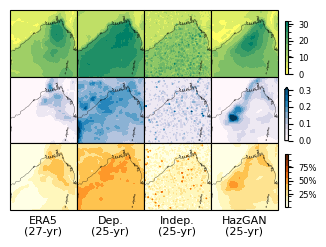

In [ ]:
from cartopy import crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import xarray as xr


plt.rcParams.update({
    'font.size': 6,
    'axes.labelsize': 7,
    'axes.titlesize': 8,
    'figure.titlesize': 8,
    'figure.titleweight': 'bold',
    'axes.titleweight': 'normal',
    'legend.fontsize': 6,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': True,
    'axes.spines.bottom': True
})

RP = 25

def damagefield(
        tree:xr.DataTree, label:str,  ds, ds_var, axs:plt.Axes, rp=10,
        add_colorbar=False, levels=10
        ) -> None:
    ds = ds.copy()
    ds["return_period"] = tree[label]['return_period']
    ds = ds.swap_dims({'sample': 'return_period'})
    ds = ds.sortby("return_period", ascending=True)
    sample = ds.sel(return_period=rp, method='nearest')
    
    # Plot on each row without colorbars
    im1 = sample.isel(field=0)[ds_var].plot.contourf(ax=axs[0], cmap="summer_r", levels=levels,
                                                     add_colorbar=False, vmin=0, vmax=32)
    im2 = sample.isel(field=1)[ds_var].plot.contourf(ax=axs[1], cmap="PuBu", levels=levels, 
                                                     add_colorbar=False, vmin=0, vmax=0.3)
    im3 = sample['damage_prob'].plot.contourf(ax=axs[2], cmap="YlOrBr", levels=levels,
                                                     add_colorbar=False, vmin=0, vmax=1)
    
    # Store the image references for later colorbar creation
    rp_approx = sample['return_period'].values.item()
    title = f"{label}\n({rp_approx:.0f}-yr)"

    if add_colorbar:
        return im1, im2, im3, title
    
    axs[0].set_title(f"{label}\n({rp_approx:.0f}-yr)", fontweight='bold')
    axs[1].set_title("")
    axs[2].set_title("")
    
    return title

# Create the figure with the appropriate layout
fig = plt.figure(figsize=(3.5, 2.6))
gs = fig.add_gridspec(3, 5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.0, hspace=0.0)

# Create axes with projections
axs = []
for row in range(3):
    row_axes = []
    for col in range(4):
        ax = fig.add_subplot(gs[row, col], projection=ccrs.PlateCarree())
        row_axes.append(ax)
    axs.append(row_axes)
axs = plt.np.array(axs)

# Create separate axes for colorbars
cbar_ax1 = fig.add_subplot(gs[0, 4])
cbar_ax2 = fig.add_subplot(gs[1, 4])
cbar_ax3 = fig.add_subplot(gs[2, 4])

# Call damagefield for the first three columns without colorbars
levels = 10
title0 = damagefield(tree, 'ERA5', train_damages, 'train', axs[:, 0], rp=RP, levels=levels)
title1 = damagefield(tree, 'Dependent', dependent_damages, 'dependent', axs[:, 1], rp=RP, levels=levels)
title2 = damagefield(tree, 'Independent', independent_damages, 'independent', axs[:, 2], rp=RP, levels=levels)

# Call the last column with colorbar flag set to True to get the image references
im1, im2, im3, title3 = damagefield(tree, 'HazGAN', fake_damages, 'fake', axs[:, 3], add_colorbar=True, rp=RP, levels=levels)

# Add colorbars using the image references from the last column
plt.colorbar(im1, cax=cbar_ax1, orientation='vertical', shrink=0.8, label='', ticks=[0, 10, 20, 30, 40], aspect=20)
plt.colorbar(im2, cax=cbar_ax2, orientation='vertical', shrink=0.8, label='', ticks=[0, 0.1, 0.2, 0.3])
plt.colorbar(im3, cax=cbar_ax3, orientation='vertical', shrink=0.8, label='', ticks=[0.25, 0.5, 0.75], format=plt.matplotlib.ticker.PercentFormatter(1, 0))
for ax in [cbar_ax1, cbar_ax2, cbar_ax3]:
    pos = ax.get_position()
    # [left, bottom, width, height] -> making them 20% thinner and 10% shorter
    ax.set_position([pos.x0 + 0.02, pos.y0 + 0.01, pos.width * 1.1, pos.height * 0.8])
    
# Set labels and features for all axes
for ax in axs.flat:
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.2)

# axs[0, 0].set_ylabel(r"Wind speed (ms$^{-1}$)")
# axs[1, 0].set_ylabel("Precipitation (m)")
# axs[2, 0].set_ylabel("Damage probability")

# Add titles to the top row
axs[-1, 0].set_title(title0, y=-.5)
axs[-1, 1].set_title(f"Dep.\n({RP}-yr)", y=-0.5)
axs[-1, 2].set_title(f"Indep.\n({RP}-yr)", y=-.5)
axs[-1, 3].set_title(f"HazGAN\n({RP}-yr)", y=-.5)

if savefigs:
    fig.savefig(
        figdir / f"{RP}yr_mangrove_damages.png",
        transparent=True,
        dpi=300,
    )

In [ ]:
def assign_rps(
        tree:xr.DataTree, label:str, ds:xr.Dataset,
        rps:list=[5, 10, 25, 50, 100]
        ) -> xr.Dataset:
    ds = ds.copy()
    ds["return_period"] = tree[label]['return_period']
    ds["expected_damage"] = tree[label]['expected_damage']
    ds = ds.swap_dims({'sample': 'return_period'})
    ds = ds.sortby("return_period", ascending=True)
    sample = ds.sel(return_period=rps, method='nearest')
    return sample

all_rps = tree['ERA5']['return_period'].values.tolist()
sample_rps = [5, 10, 25, 50, 100, 500]
train_rps = assign_rps(tree, 'ERA5', train_damages, rps=sample_rps)
gan_rps = assign_rps(tree, 'HazGAN', fake_damages, rps=sample_rps)
indep_rps = assign_rps(tree, 'Independent', independent_damages, rps=sample_rps)
dep_rps = assign_rps(tree, 'Dependent', dependent_damages, rps=sample_rps)

In [ ]:
def make_risk_profile_table(
        rps:list, train_rps:xr.Dataset, gan_rps:xr.Dataset,
        indep_rps:xr.Dataset, dep_rps:xr.Dataset,
        fraction:bool=True
        ) -> pd.DataFrame:
    
    if fraction:
        constant = mangrove_area
    else:
        constant = 1.0
    data = []
    for rp in rps:

        # era5_rp = train_rps.sel(return_period=rp, method='nearest')
        # data.append(['ERA5', 'Expected damage area (km²)', rp, era5_rp['expected_damage'].values.item() / constant])
        # data.append(['ERA5', 'Return period (years)', rp, era5_rp['return_period'].values.item()])

        gan_rp = gan_rps.sel(return_period=rp, method='nearest')
        data.append(['HazGAN', 'Expected damage area (km²)', rp, gan_rp['expected_damage'].values.item() / constant])
        data.append(['HazGAN', 'Return period (years)', rp, gan_rp['return_period'].values.item()])

        indep_rp = indep_rps.sel(return_period=rp, method='nearest')
        data.append(['Independent', 'Expected damage area (km²)', rp, indep_rp['expected_damage'].values.item() / constant])
        data.append(['Independent', 'Return period (years)', rp, indep_rp['return_period'].values.item()])

        dep_rp = dep_rps.sel(return_period=rp, method='nearest')
        data.append(['Dependent', 'Expected damage area (km²)', rp, dep_rp['expected_damage'].values.item() / constant])
        data.append(['Dependent', 'Return period (years)', rp, dep_rp['return_period'].values.item()])
    return pd.DataFrame(data, columns=['Method', 'Deviation', 'Return Period', 'Value'])

df_risk_profile = make_risk_profile_table(
    sample_rps, train_rps, gan_rps, indep_rps, dep_rps, fraction=False
)

df_pivot = df_risk_profile.pivot_table(
    index=['Method', 'Deviation'],
    columns='Return Period',
    values='Value'
)
# Print the DataFrame
print(df_pivot.to_string(float_format='%.2f'))

Return Period                              5       10      25      50      100     500
Method      Deviation                                                                 
Dependent   Expected damage area (km²) 3173.39 3488.15 3780.44 4053.99 4311.42 4785.14
            Return period (years)         4.64   10.00   21.54   46.42  100.00  464.16
HazGAN      Expected damage area (km²) 2303.81 2482.59 2619.81 2827.21 2961.19 3301.93
            Return period (years)         4.99   10.08   24.70   49.41   98.82  494.10
Independent Expected damage area (km²) 1384.69 1437.50 1496.78 1546.22 1590.33 1660.71
            Return period (years)         5.00   10.00   25.06   50.11  100.23  513.68


In [ ]:
gan_err = gan_rps["expected_damage"].values - train_rps["expected_damage"].values
gan_dev = gan_rps["return_period"].values - train_rps["return_period"].values
indep_err = indep_rps["expected_damage"].values - train_rps["expected_damage"].values
indep_dev = indep_rps["return_period"].values - train_rps["return_period"].values
dep_err = dep_rps["expected_damage"].values - train_rps["expected_damage"].values
dep_dev = dep_rps["return_period"].values - train_rps["return_period"].values

gan_err   = list(gan_err)
indep_err = list(indep_err)
dep_err   = list(dep_err)
gan_dev   = list(gan_dev)
indep_dev = list(indep_dev)
dep_dev   = list(dep_dev)

In [ ]:
train_rps = assign_rps(tree, 'ERA5', train_damages, rps=all_rps)
gan_rps = assign_rps(tree, 'HazGAN', fake_damages, rps=all_rps)
indep_rps = assign_rps(tree, 'Independent', independent_damages, rps=all_rps)
dep_rps = assign_rps(tree, 'Dependent', dependent_damages, rps=all_rps)

def calculate_mae(ds1, ds2, var):
    """Calculate mean absolute error between two datasets."""
    return np.mean(np.abs(ds1[var].values - ds2[var].values))

mae_gan = calculate_mae(train_rps, gan_rps, 'expected_damage')
mae_indep = calculate_mae(train_rps, indep_rps, 'expected_damage')
mae_dep = calculate_mae(train_rps, dep_rps, 'expected_damage')

mae_gan_rp = calculate_mae(train_rps, gan_rps, 'return_period')
mae_indep_rp = calculate_mae(train_rps, indep_rps, 'return_period')
mae_dep_rp = calculate_mae(train_rps, dep_rps, 'return_period') 

# append the MAE errors
gan_err += [mae_gan]
indep_err += [mae_indep]
dep_err += [mae_dep]
gan_dev += [mae_gan_rp]
indep_dev += [mae_indep_rp]
dep_dev += [mae_dep_rp]
sample_rps.append('MAE')  # Add MAE to the list of return periods

In [ ]:
data = []

for i, rp in enumerate(sample_rps):
    data.append(['HazGAN', 'Expected damage area (km²)', rp, gan_err[i]])
    data.append(['HazGAN', 'Return period (years)', rp, gan_dev[i]])

    data.append(['Independent', 'Expected damage area (km²)', rp, indep_err[i]])
    data.append(['Independent', 'Return period (years)', rp, indep_dev[i]])

    data.append(['Dependent', 'Expected damage area (km²)', rp, dep_err[i]])
    data.append(['Dependent', 'Return period (years)', rp, dep_dev[i]])


df_long = pd.DataFrame(data, columns=['Method', 'Deviation', 'Return Period', 'Value'])
df_pivot = df_long.pivot_table(index=['Method', 'Deviation'], 
                               columns='Return Period', 
                               values='Value')

formatter = lambda x: f'{x} yr' if isinstance(x, int) else x
df_pivot.columns = [formatter(col) for col in df_pivot.columns]


# change row order
df_pivot = df_pivot.reindex(
    index=[
        ('HazGAN', 'Expected damage area (km²)'),
        ('HazGAN', 'Return period (years)'),
        ('Independent', 'Expected damage area (km²)'),
        ('Independent', 'Return period (years)'),
        ('Dependent', 'Expected damage area (km²)'),
        ('Dependent', 'Return period (years)')
    ]
)
print(df_pivot.to_string(float_format='%.2f'))

                                           5 yr    10 yr    25 yr    50 yr   100 yr   500 yr     MAE
Method      Deviation                                                                               
HazGAN      Expected damage area (km²)  -147.40  -172.92  -154.79    -8.85    -5.92   334.82   54.05
            Return period (years)         -0.11    -0.11    -2.48     8.64    17.28   412.56    0.02
Independent Expected damage area (km²) -1066.51 -1218.01 -1277.82 -1289.83 -1376.78 -1306.40  484.37
            Return period (years)         -0.10    -0.19    -2.12     9.34    18.69   432.14    0.01
Dependent   Expected damage area (km²)   722.18   832.63  1005.84  1217.94  1344.31  1818.02 1062.16
            Return period (years)         -0.45    -0.19    -5.64     5.65    18.46   382.62    0.64


In [ ]:
latex_table = df_pivot.to_latex(
    float_format='%.2f',
    escape=False,
    header=True,
    multirow=True,
    multicolumn_format='c',
    caption="Expected damage area and return period deviations for GAN, independent, and dependent generated samples.",
    label="tab:riskprofile"
)

print(latex_table)

\begin{table}
\caption{Expected damage area and return period deviations for GAN, independent, and dependent generated samples.}
\label{tab:riskprofile}
\begin{tabular}{llrrrrrrr}
\toprule
 &  & 5 yr & 10 yr & 25 yr & 50 yr & 100 yr & 500 yr & MAE \\
Method & Deviation &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{2}{*}{HazGAN} & Expected damage area (km²) & -147.40 & -172.92 & -154.79 & -8.85 & -5.92 & 334.82 & 54.05 \\
 & Return period (years) & -0.11 & -0.11 & -2.48 & 8.64 & 17.28 & 412.56 & 0.02 \\
\cline{1-9}
\multirow[t]{2}{*}{Independent} & Expected damage area (km²) & -1066.51 & -1218.01 & -1277.82 & -1289.83 & -1376.78 & -1306.40 & 484.37 \\
 & Return period (years) & -0.10 & -0.19 & -2.12 & 9.34 & 18.69 & 432.14 & 0.01 \\
\cline{1-9}
\multirow[t]{2}{*}{Dependent} & Expected damage area (km²) & 722.18 & 832.63 & 1005.84 & 1217.94 & 1344.31 & 1818.02 & 1062.16 \\
 & Return period (years) & -0.45 & -0.19 & -5.64 & 5.65 & 18.46 & 382.62 & 0.64 \\
\cline{1-9}
\bottomrule
\end{tabu

In [ ]:
print("Table of errors")
data = []

for i, rp in enumerate(sample_rps):
    data.append(['HazGAN', 'Expected damage area (km²)', rp, gan_err[i]])
    data.append(['HazGAN', 'Return period (years)', rp, gan_dev[i]])

    data.append(['Independent', 'Expected damage area (km²)', rp, indep_err[i]])
    data.append(['Independent', 'Return period (years)', rp, indep_dev[i]])

    data.append(['Dependent', 'Expected damage area (km²)', rp, dep_err[i]])
    data.append(['Dependent', 'Return period (years)', rp, dep_dev[i]])


df_long = pd.DataFrame(data, columns=['Method', 'Deviation', 'Return Period', 'Value'])
df_pivot = df_long.pivot_table(index=['Method', 'Deviation'], 
                               columns='Return Period', 
                               values='Value')

formatter = lambda x: f'{x} yr' if isinstance(x, int) else x
df_pivot.columns = [formatter(col) for col in df_pivot.columns]


# change row order
df_pivot = df_pivot.reindex(
    index=[
        ('HazGAN', 'Expected damage area (km²)'),
        ('HazGAN', 'Return period (years)'),
        ('Independent', 'Expected damage area (km²)'),
        ('Independent', 'Return period (years)'),
        ('Dependent', 'Expected damage area (km²)'),
        ('Dependent', 'Return period (years)')
    ]
)
print(df_pivot.to_string(float_format='%.2f'))

Table of errors
                                           5 yr    10 yr    25 yr    50 yr   100 yr   500 yr     MAE
Method      Deviation                                                                               
HazGAN      Expected damage area (km²)  -147.40  -172.92  -154.79    -8.85    -5.92   334.82   54.05
            Return period (years)         -0.11    -0.11    -2.48     8.64    17.28   412.56    0.02
Independent Expected damage area (km²) -1066.51 -1218.01 -1277.82 -1289.83 -1376.78 -1306.40  484.37
            Return period (years)         -0.10    -0.19    -2.12     9.34    18.69   432.14    0.01
Dependent   Expected damage area (km²)   722.18   832.63  1005.84  1217.94  1344.31  1818.02 1062.16
            Return period (years)         -0.45    -0.19    -5.64     5.65    18.46   382.62    0.64


In [ ]:
train_rps

<xarray.Dataset> Size: 20MB
Dimensions:          (return_period: 150, lat: 64, lon: 64, field: 3)
Coordinates:
  * return_period    (return_period) float64 1kB 0.5436 0.5472 ... 40.77 81.54
  * lat              (lat) float64 512B 9.994 10.23 10.47 ... 24.53 24.77 25.01
  * lon              (lon) float64 512B 79.99 80.23 80.47 ... 94.53 94.77 95.01
  * field            (field) <U4 48B 'u10' 'tp' 'mslp'
    sample           (return_period) int64 1kB 87 97 68 81 104 ... 57 50 26 47
Data variables:
    train            (return_period, lat, lon, field) float64 15MB ...
    damage_prob      (return_period, lat, lon) float64 5MB ...
    rate             float64 8B 1.852
    expected_damage  (return_period) float64 1kB 705.5 714.7 ... 2.967e+03

In [ ]:
train_rps.sel(return_period=5)

KeyError: "not all values found in index 'return_period'. Try setting the `method` keyword argument (example: method='nearest')."

In [ ]:
train_rps.sel(return_period=5, method="nearest")

<xarray.Dataset> Size: 132kB
Dimensions:          (lat: 64, lon: 64, field: 3)
Coordinates:
  * lat              (lat) float64 512B 9.994 10.23 10.47 ... 24.53 24.77 25.01
  * lon              (lon) float64 512B 79.99 80.23 80.47 ... 94.53 94.77 95.01
  * field            (field) <U4 48B 'u10' 'tp' 'mslp'
    sample           int64 8B 103
    return_period    float64 8B 5.096
Data variables:
    train            (lat, lon, field) float64 98kB ...
    damage_prob      (lat, lon) float64 33kB ...
    rate             float64 8B 1.852
    expected_damage  float64 8B 2.451e+03

In [ ]:
train_rps.sel(return_period=5, method="nearest")["expected_damage"]

<xarray.DataArray 'expected_damage' ()> Size: 8B
array(2451.20825413)
Coordinates:
    sample         int64 8B 103
    return_period  float64 8B 5.096

In [ ]:
train_rps.sel(return_period=5, method="nearest")["expected_damage"].values

array(2451.20825413)

In [ ]:
# print the train results
print("Expected damage area (km²) for return period 5 years:")
print(train_rps.sel(return_period=5, method="nearest")["expected_damage"].values)
print("Expected damage area (km²) for return period 100 years:")
print(train_rps.sel(return_period=100, method="nearest")["expected_damage"].values)

Expected damage area (km²) for return period 5 years:
2451.208254132738
Expected damage area (km²) for return period 100 years:
2967.1149975408075


In [ ]:
train_rps = assign_rps(tree, 'ERA5', train_damages, rps=all_rps)
gan_rps = assign_rps(tree, 'HazGAN', fake_damages, rps=all_rps)
indep_rps = assign_rps(tree, 'Independent', independent_damages, rps=all_rps)
dep_rps = assign_rps(tree, 'Dependent', dependent_damages, rps=all_rps)

def calculate_mae(ds1, ds2, var):
    """Calculate mean absolute error between two datasets."""
    return np.mean(np.abs(ds1[var].values - ds2[var].values))

mae_gan = calculate_mae(train_rps, gan_rps, 'expected_damage')
mae_indep = calculate_mae(train_rps, indep_rps, 'expected_damage')
mae_dep = calculate_mae(train_rps, dep_rps, 'expected_damage')

mae_gan_rp = calculate_mae(train_rps, gan_rps, 'return_period')
mae_indep_rp = calculate_mae(train_rps, indep_rps, 'return_period')
mae_dep_rp = calculate_mae(train_rps, dep_rps, 'return_period') 

# append the MAE errors
gan_err += [mae_gan]
indep_err += [mae_indep]
dep_err += [mae_dep]
gan_dev += [mae_gan_rp]
indep_dev += [mae_indep_rp]
dep_dev += [mae_dep_rp]
sample_rps.append('MAE')  # Add MAE to the list of return periods

In [ ]:
# print the train results
print("Expected damage area (km²) for return period 5 years:")
print(train_rps.sel(return_period=5, method="nearest")["expected_damage"].values)
print("Expected damage area (km²) for return period 100 years:")
print(train_rps.sel(return_period=100, method="nearest")["expected_damage"].values)

Expected damage area (km²) for return period 5 years:
2451.208254132738
Expected damage area (km²) for return period 100 years:
2967.1149975408075


In [ ]:
print("Table of errors")
data = []

for i, rp in enumerate(sample_rps):
    data.append(['HazGAN', 'Expected damage area (km²)', rp, gan_err[i]])
    data.append(['HazGAN', 'Return period (years)', rp, gan_dev[i]])

    data.append(['Independent', 'Expected damage area (km²)', rp, indep_err[i]])
    data.append(['Independent', 'Return period (years)', rp, indep_dev[i]])

    data.append(['Dependent', 'Expected damage area (km²)', rp, dep_err[i]])
    data.append(['Dependent', 'Return period (years)', rp, dep_dev[i]])


df_long = pd.DataFrame(data, columns=['Method', 'Deviation', 'Return Period', 'Value'])
df_pivot = df_long.pivot_table(index=['Method', 'Deviation'], 
                               columns='Return Period', 
                               values='Value')

formatter = lambda x: f'{x} yr' if isinstance(x, int) else x
df_pivot.columns = [formatter(col) for col in df_pivot.columns]


# change row order
df_pivot = df_pivot.reindex(
    index=[
        ('HazGAN', 'Expected damage area (km²)'),
        ('HazGAN', 'Return period (years)'),
        ('Independent', 'Expected damage area (km²)'),
        ('Independent', 'Return period (years)'),
        ('Dependent', 'Expected damage area (km²)'),
        ('Dependent', 'Return period (years)')
    ]
)
print(df_pivot.to_string(float_format='%.2f'))

Table of errors
                                           5 yr    10 yr    25 yr    50 yr   100 yr   500 yr     MAE
Method      Deviation                                                                               
HazGAN      Expected damage area (km²)  -147.40  -172.92  -154.79    -8.85    -5.92   334.82   54.05
            Return period (years)         -0.11    -0.11    -2.48     8.64    17.28   412.56    0.02
Independent Expected damage area (km²) -1066.51 -1218.01 -1277.82 -1289.83 -1376.78 -1306.40  484.37
            Return period (years)         -0.10    -0.19    -2.12     9.34    18.69   432.14    0.01
Dependent   Expected damage area (km²)   722.18   832.63  1005.84  1217.94  1344.31  1818.02 1062.16
            Return period (years)         -0.45    -0.19    -5.64     5.65    18.46   382.62    0.64


In [ ]:
# print the train results
print("Expected damage area (km²) for return period 5 years:")
res5y4 = train_rps.sel(return_period=5, method="nearest")["expected_damage"].values.item()
print(f"{res5y4:.2f}, which is {res5y4/mangrove_area:.2%} of total mangrove area")
print("Expected damage area (km²) for return period 100 years:")
print(train_rps.sel(return_period=100, method="nearest")["expected_damage"].values)

Expected damage area (km²) for return period 5 years:
2451.21, which is 24.72% of total mangrove area
Expected damage area (km²) for return period 100 years:
2967.1149975408075


In [ ]:
# print the train results
print("Expected damage area (km²) for return period 5 years:")
res5y4 = train_rps.sel(return_period=5, method="nearest")["expected_damage"].values.item()
print(f"{res5y4:.2f}, which is {res5y4/mangrove_area:.2%} of total mangrove area")
print("Expected damage area (km²) for return period 100 years:")
res100yr = train_rps.sel(return_period=100, method="nearest")["expected_damage"].values.item()
print(f"{res100yr:.2f}, which is {res100yr/mangrove_area:.2%} of total mangrove area")
# print(train_rps.sel(return_period=100, method="nearest")["expected_damage"].values)

Expected damage area (km²) for return period 5 years:
2451.21, which is 24.72% of total mangrove area
Expected damage area (km²) for return period 100 years:
2967.11, which is 29.92% of total mangrove area


In [ ]:
# print the train results
print("Expected damage area (km²) for return period 5 years:")
res5yr = train_rps.sel(return_period=5, method="nearest")["expected_damage"].values.item()
print(f"    {res5yr:.2f}, which is {res5yr/mangrove_area:.2%} of total mangrove area")
print("Expected damage area (km²) for return period 100 years:")
res100yr = train_rps.sel(return_period=100, method="nearest")["expected_damage"].values.item()
print(f"    {res100yr:.2f}, which is {res100yr/mangrove_area:.2%} of total mangrove area")
# print(train_rps.sel(return_period=100, method="nearest")["expected_damage"].values)

Expected damage area (km²) for return period 5 years:
    2451.21, which is 24.72% of total mangrove area
Expected damage area (km²) for return period 100 years:
    2967.11, which is 29.92% of total mangrove area


In [ ]:
# print the train results
print(f"Train:\n-------")
print("Expected damage area (km²) for return period 5 years:")
res5yr = train_rps.sel(return_period=5, method="nearest")["expected_damage"].values.item()
print(f"    {res5yr:.2f}, which is {res5yr/mangrove_area:.2%} of total mangrove area")
print("Expected damage area (km²) for return period 100 years:")
res100yr = train_rps.sel(return_period=100, method="nearest")["expected_damage"].values.item()
print(f"    {res100yr:.2f}, which is {res100yr/mangrove_area:.2%} of total mangrove area")

Train:
-------
Expected damage area (km²) for return period 5 years:
    2451.21, which is 24.72% of total mangrove area
Expected damage area (km²) for return period 100 years:
    2967.11, which is 29.92% of total mangrove area


In [ ]:
# print the train results
print(f"Train:\n-------")
print("Expected damage area (km²) for return period 5 years:")
res5yr = train_rps.sel(return_period=5, method="nearest")["expected_damage"].values.item()
print(f"    {res5yr:.2f}, which is {res5yr/mangrove_area:.2%} of total mangrove area")
print("Expected damage area (km²) for return period 100 years:")
res100yr = train_rps.sel(return_period=100, method="nearest")["expected_damage"].values.item()
print(f"    {res100yr:.2f}, which is {res100yr/mangrove_area:.2%} of total mangrove area")

print(f"HazGAN:\n-------")
print("Expected damage area (km²) for return period 5 years:")
res5yr = gan_rps.sel(return_period=5, method="nearest")["expected_damage"].values.item()
print(f"    {res5yr:.2f}, which is {res5yr/mangrove_area:.2%} of total mangrove area")
print("Expected damage area (km²) for return period 100 years:")
res100yr = gan_rps.sel(return_period=100, method="nearest")["expected_damage"].values.item()
print(f"    {res100yr:.2f}, which is {res100yr/mangrove_area:.2%} of total mangrove area")

Train:
-------
Expected damage area (km²) for return period 5 years:
    2451.21, which is 24.72% of total mangrove area
Expected damage area (km²) for return period 100 years:
    2967.11, which is 29.92% of total mangrove area
HazGAN:
-------
Expected damage area (km²) for return period 5 years:
    2309.12, which is 23.28% of total mangrove area
Expected damage area (km²) for return period 100 years:
    2891.09, which is 29.15% of total mangrove area


In [ ]:
# print the train results
print(f"Train:\n-------")
print("Expected damage area (km²) for return period 5 years:")
res5yr = train_rps.sel(return_period=5, method="nearest")["expected_damage"].values.item()
print(f"    {res5yr:.2f}, which is {res5yr/mangrove_area:.2%} of total mangrove area")
print("Expected damage area (km²) for return period 100 years:")
res100yr = train_rps.sel(return_period=100, method="nearest")["expected_damage"].values.item()
print(f"    {res100yr:.2f}, which is {res100yr/mangrove_area:.2%} of total mangrove area")

print(f"HazGAN:\n-------")
print("Expected damage area (km²) for return period 5 years:")
res5yr = gan_rps.sel(return_period=5, method="nearest")["expected_damage"].values.item()
print(f"    {res5yr:.2f}, which is {res5yr/mangrove_area:.2%} of total mangrove area")
print("Expected damage area (km²) for return period 100 years:")
res100yr = gan_rps.sel(return_period=100, method="nearest")["expected_damage"].values.item()
print(f"    {res100yr:.2f}, which is {res100yr/mangrove_area:.2%} of total mangrove area")

print(f"Independent:\n-------")
print("Expected damage area (km²) for return period 5 years:")
res5yr = indep_rps.sel(return_period=5, method="nearest")["expected_damage"].values.item()
print(f"    {res5yr:.2f}, which is {res5yr/mangrove_area:.2%} of total mangrove area")
print("Expected damage area (km²) for return period 100 years:")
res100yr = indep_rps.sel(return_period=100, method="nearest")["expected_damage"].values.item()
print(f"    {res100yr:.2f}, which is {res100yr/mangrove_area:.2%} of total mangrove area") 

print(f"Dependent:\n-------")
print("Expected damage area (km²) for return period 5 years:")
res5yr = dep_rps.sel(return_period=5, method="nearest")["expected_damage"].values.item()
print(f"    {res5yr:.2f}, which is {res5yr/mangrove_area:.2%} of total mangrove area")
print("Expected damage area (km²) for return period 100 years:")
res100yr = dep_rps.sel(return_period=100, method="nearest")["expected_damage"].values.item()
print(f"    {res100yr:.2f}, which is {res100yr/mangrove_area:.2%} of total mangrove area")

Train:
-------
Expected damage area (km²) for return period 5 years:
    2451.21, which is 24.72% of total mangrove area
Expected damage area (km²) for return period 100 years:
    2967.11, which is 29.92% of total mangrove area
HazGAN:
-------
Expected damage area (km²) for return period 5 years:
    2309.12, which is 23.28% of total mangrove area
Expected damage area (km²) for return period 100 years:
    2891.09, which is 29.15% of total mangrove area
Independent:
-------
Expected damage area (km²) for return period 5 years:
    1385.87, which is 13.97% of total mangrove area
Expected damage area (km²) for return period 100 years:
    1583.83, which is 15.97% of total mangrove area
Dependent:
-------
Expected damage area (km²) for return period 5 years:


InvalidIndexError: Reindexing only valid with uniquely valued Index objects

In [ ]:
dep_rps

<xarray.Dataset> Size: 20MB
Dimensions:          (return_period: 150, lat: 64, lon: 64, field: 3)
Coordinates:
  * return_period    (return_period) float64 1kB 1.0 1.0 1.0 ... 46.42 100.0
  * lat              (lat) float64 512B 9.994 10.23 10.47 ... 24.53 24.77 25.01
  * lon              (lon) float64 512B 79.99 80.23 80.47 ... 94.53 94.77 95.01
  * field            (field) <U4 48B 'u10' 'tp' 'mslp'
    sample           (return_period) int64 1kB 0 0 0 0 0 0 0 0 ... 3 3 4 4 4 5 6
Data variables:
    dependent        (return_period, lat, lon, field) float64 15MB ...
    uniform          (return_period, field) float64 4kB ...
    damage_prob      (return_period, lat, lon) float64 5MB ...
    expected_damage  (return_period) float64 1kB 2.453e+03 ... 4.311e+03

In [ ]:
def make_risk_profile_table(
        rps:list, train_rps:xr.Dataset, gan_rps:xr.Dataset,
        indep_rps:xr.Dataset, dep_rps:xr.Dataset,
        fraction:bool=True
        ) -> pd.DataFrame:
    
    if fraction:
        constant = mangrove_area
    else:
        constant = 1.0
    data = []
    for rp in rps:

        era5_rp = train_rps.sel(return_period=rp, method='nearest')
        data.append(['ERA5', 'Expected damage area (km²)', rp, era5_rp['expected_damage'].values.item() / constant])
        data.append(['ERA5', 'Return period (years)', rp, era5_rp['return_period'].values.item()])

        gan_rp = gan_rps.sel(return_period=rp, method='nearest')
        data.append(['HazGAN', 'Expected damage area (km²)', rp, gan_rp['expected_damage'].values.item() / constant])
        data.append(['HazGAN', 'Return period (years)', rp, gan_rp['return_period'].values.item()])

        indep_rp = indep_rps.sel(return_period=rp, method='nearest')
        data.append(['Independent', 'Expected damage area (km²)', rp, indep_rp['expected_damage'].values.item() / constant])
        data.append(['Independent', 'Return period (years)', rp, indep_rp['return_period'].values.item()])

        dep_rp = dep_rps.sel(return_period=rp, method='nearest')
        data.append(['Dependent', 'Expected damage area (km²)', rp, dep_rp['expected_damage'].values.item() / constant])
        data.append(['Dependent', 'Return period (years)', rp, dep_rp['return_period'].values.item()])
    return pd.DataFrame(data, columns=['Method', 'Deviation', 'Return Period', 'Value'])

df_risk_profile = make_risk_profile_table(
    sample_rps, train_rps, gan_rps, indep_rps, dep_rps, fraction=False
)

df_pivot = df_risk_profile.pivot_table(
    index=['Method', 'Deviation'],
    columns='Return Period',
    values='Value'
)
# Print the DataFrame
print(df_pivot.to_string(float_format='%.2f'))

InvalidIndexError: Reindexing only valid with uniquely valued Index objects

In [ ]:
def make_risk_profile_table(
        rps:list, train_rps:xr.Dataset, gan_rps:xr.Dataset,
        indep_rps:xr.Dataset, dep_rps:xr.Dataset,
        fraction:bool=True
        ) -> pd.DataFrame:
    
    if fraction:
        constant = mangrove_area
    else:
        constant = 1.0
    data = []
    for rp in rps:

        # era5_rp = train_rps.sel(return_period=rp, method='nearest')
        # data.append(['ERA5', 'Expected damage area (km²)', rp, era5_rp['expected_damage'].values.item() / constant])
        # data.append(['ERA5', 'Return period (years)', rp, era5_rp['return_period'].values.item()])

        gan_rp = gan_rps.sel(return_period=rp, method='nearest')
        data.append(['HazGAN', 'Expected damage area (km²)', rp, gan_rp['expected_damage'].values.item() / constant])
        data.append(['HazGAN', 'Return period (years)', rp, gan_rp['return_period'].values.item()])

        indep_rp = indep_rps.sel(return_period=rp, method='nearest')
        data.append(['Independent', 'Expected damage area (km²)', rp, indep_rp['expected_damage'].values.item() / constant])
        data.append(['Independent', 'Return period (years)', rp, indep_rp['return_period'].values.item()])

        dep_rp = dep_rps.sel(return_period=rp, method='nearest')
        data.append(['Dependent', 'Expected damage area (km²)', rp, dep_rp['expected_damage'].values.item() / constant])
        data.append(['Dependent', 'Return period (years)', rp, dep_rp['return_period'].values.item()])
    return pd.DataFrame(data, columns=['Method', 'Deviation', 'Return Period', 'Value'])

df_risk_profile = make_risk_profile_table(
    sample_rps, train_rps, gan_rps, indep_rps, dep_rps, fraction=False
)

df_pivot = df_risk_profile.pivot_table(
    index=['Method', 'Deviation'],
    columns='Return Period',
    values='Value'
)
# Print the DataFrame
print(df_pivot.to_string(float_format='%.2f'))

InvalidIndexError: Reindexing only valid with uniquely valued Index objects

In [ ]:
"""
Plots mangrove damages and compares 1-in-10 year events.

1. Multiplies the damage probability with the mangrove area in each grid cell to get expected damage area.
2. Assign return periods based on expected mangrove damage.
3. Plot risk profile and damage probability fields.
"""
# %%
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
from environs import Env
import matplotlib.pyplot as plt
from pathlib import Path

from utils.statistics import calculate_total_return_periods

bay_of_bengal_crs = 24346
savefigs = False
FRACTION = False  # whether to divide by mangrove area

env = Env()
env.read_env()

True

In [ ]:
samples_dir    = Path(env.str("SAMPLES_DIR"))
mangroves_dir  = Path(env.str("MANGROVE_DIR"))
mangroves_path = Path(env.str("MANGROVES"))
figdir = Path(env.str("FIG_DIR")) / "mangroves"
figdir.mkdir(parents=True, exist_ok=True)

train_damages       = xr.open_dataset(mangroves_dir / "results" / "train_damages.nc")
fake_damages        = xr.open_dataset(mangroves_dir / "results" / "fake_damages.nc")
independent_damages = xr.open_dataset(mangroves_dir / "results" / "independent_damages.nc")
dependent_damages   = xr.open_dataset(mangroves_dir / "results" / "dependent_damages.nc")

# different rates for different datasets
rate = train_damages.sizes["sample"] / 81
train_damages['rate']       = rate
fake_damages['rate']        = rate
independent_damages['rate'] = 1249 / 81

In [ ]:
mangrove_grid_path = mangroves_dir / "mangrove_grid.nc"

if not os.path.exists(mangrove_grid_path):
    from shapely.geometry import box
    from utils import mangroveDamageModel

    #  Step 1: Clip mangroves to bay of bengal
    aoi = box(80.0, 10.0, 95.0, 25.0)  # Bay of Bengal bounding box
    mangroves = gpd.read_file(mangroves_path, mask=aoi)
    mangroves = mangroves.set_crs(epsg=4326).drop(columns='PXLVAL')
    mangroves['area']  = mangroves.to_crs(bay_of_bengal_crs).area

    # Step 2: Project mangroves to grid
    model = mangroveDamageModel()
    mangrove_grid = model.intersect_mangroves_with_grid(mangroves, train_damages.isel(sample=0))
    mangrove_grid.to_netcdf(mangrove_grid_path)

mangrove_grid = xr.open_dataset(mangrove_grid_path)
mangrove_area = mangrove_grid["area"].sum().values.item()
print(f"Total mangrove area: {mangrove_area:.2f} km²")

Total mangrove area: 9917.85 km²


In [ ]:
train_damages['expected_damage']       = train_damages['damage_prob'] * mangrove_grid['area']
fake_damages['expected_damage']        = fake_damages['damage_prob'] * mangrove_grid['area']
independent_damages['expected_damage'] = independent_damages['damage_prob'] * mangrove_grid['area']
dependent_damages['expected_damage']   = dependent_damages['damage_prob'] * mangrove_grid['area']

In [ ]:
tree = xr.DataTree()
tree['ERA5'] = xr.DataTree(train_damages)
tree['HazGAN']  = xr.DataTree(fake_damages)
tree['Independent'] = xr.DataTree(independent_damages)
tree['Dependent'] = xr.DataTree(dependent_damages)
tree.to_netcdf(mangroves_dir / "results" / "damage_areas.nc")

In [ ]:
def calculate_total_return_periods(
        damages:xr.Dataset, var:str,
        fraction:bool=FRACTION,
        rate:float=rate,
        ) -> xr.Dataset:
    """
    Calculate total damages and return periods for a given variable
    in the damages dataset.
    """
    # skip root node in datatree
    if len(damages.data_vars) > 0:
        # aggregate to overall damages
        npy = rate# damages['rate'].values.item()
        totals = damages[var].sum(dim=['lat', 'lon']).to_dataset()

        if fraction:
            totals = totals / mangrove_area
        
        # calculate return periods
        N = totals[var].sizes['sample']
        rank = totals[var].rank(dim='sample')
        totals['exceedence_prob'] = 1 - rank / (1 + N)
        totals['return_period'] = 1 / (npy * totals['exceedence_prob'])
        totals = totals.sortby('return_period')
        return totals

tree = tree.map_over_datasets(calculate_total_return_periods, 'expected_damage')

# calculate return periods differently for dependent damages
tree['Dependent'] = dependent_damages
tree['Dependent']['expected_damage'] = tree['Dependent']['expected_damage'].sum(dim=['lat', 'lon'])
if FRACTION:
    tree['Dependent']['expected_damage'] =  tree['Dependent']['expected_damage'] / mangrove_area

In [ ]:
xmin = min([ds['return_period'].min() for ds in tree.values()]).data.item()
xmax = max([ds['return_period'].max() for ds in tree.values()]).data.item()
ymin = min([ds['expected_damage'].min() for ds in tree.values()]).data.item()
ymax = max([ds['expected_damage'].max() for ds in tree.values()]).data.item()

(81,)
(494,)
(4101,)
(9,)


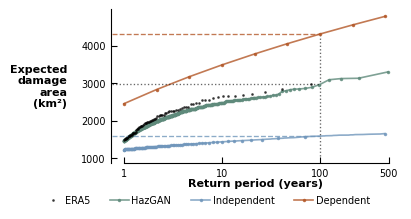

In [ ]:
def riskprofileplot(tree:xr.DataTree, label:str, ax:plt.Axes,
                    minrp:float=1, maxrp:float=500, **kwargs):
    ds = tree[label].to_dataset()
    ds = ds.where(ds['return_period'] >= minrp, drop=True)
    ds = ds.where(ds['return_period'] <= maxrp, drop=True)
    print(ds["expected_damage"].shape)
    ax.plot(ds['return_period'], ds['expected_damage'], label=label, **kwargs)

plt.rcParams.update({
    'font.size': 7,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'figure.titlesize': 8,
    'figure.titleweight': 'bold',
    'axes.titleweight': 'normal',
    'legend.fontsize': 7,
    'legend.frameon': False,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': True,
    'axes.spines.bottom': True
})

c0, c1, c2, c3 ='#4D4D4D', '#7096BB','#5F8A7B', '#B35828'
lw = 1.2
scatter_kwargs = {'linestyle': 'none', 'marker': 'o', 'mfc': 'k',
                  'mec': 'k', 'mew': 0.25, 'alpha': 0.8, 'ms': 1.5}
line_kwargs = {'linewidth': lw, 'alpha': 0.8, 'marker': 'o', 'ms': 1.5} #, 'mfc': 'none'

fig, ax = plt.subplots(figsize=(3.75, 2))

riskprofileplot(tree, 'ERA5', ax, color='k', **scatter_kwargs, zorder=10)
riskprofileplot(tree, 'HazGAN', ax, color=c2, **line_kwargs, markevery=1)
riskprofileplot(tree, 'Independent', ax, color=c1, zorder=0, **line_kwargs, markevery=50)
riskprofileplot(tree, 'Dependent', ax, color=c3, **line_kwargs)

def rp_damages(tree:xr.DataTree, label:str, rp:float) -> xr.Dataset:
    ds = tree[label].to_dataset()
    ds = ds.swap_dims({'sample': 'return_period'})
    damages = ds.sel(return_period=rp, method='nearest')["expected_damage"]
    return damages.values.item()


ax.vlines(100, ax.get_ylim()[0], rp_damages(tree, 'Dependent', 100), color='k', linestyle=":", alpha=0.6, linewidth=0.8 * lw, zorder=1)
ax.hlines(rp_damages(tree, 'ERA5', 100), 0, 100, color='k', linestyle=":", alpha=0.6, linewidth=0.8 * lw)
# ax.hlines(rp_damages(tree, 'HazGAN', 100),0, 100, color=c2, linestyle="--", alpha=0.8, linewidth=0.8 * lw)
ax.hlines(rp_damages(tree, 'Independent', 100),0, 100, color=c1, linestyle="--", alpha=0.8, linewidth=0.8 * lw)
ax.hlines(rp_damages(tree, 'Dependent', 100),0, 100, color=c3, linestyle="--", alpha=0.8, linewidth=0.8 * lw)

# legend options
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.33, -0.15),  # Center horizontally, below the plot
    ncol=4,  # Spread entries horizontally
    frameon=False,
    handletextpad=0.25,  # Reduce space between handle and text (default is 0.8)
    columnspacing=2.0,  # Reduce space between columns (default is 2.0)
    labelspacing=0.4
)
plt.setp(ax.get_legend().get_title(), fontsize='12', fontweight='bold')

# configure x-axis
ax.set_xscale('log')
yticks = np.array([ymin, 2000, 4000, 6000, ymax])
yticks = yticks[(yticks > ymin) & (yticks <= ymax)]
yticklabels = [f"{y:.0f}" for y in yticks]

ax.set_xticks([1, 10, 100, 500], labels=['1', '10', '100', '500'])
ax.spines['bottom'].set_bounds(1, 500)

# ticks config
ax.tick_params(direction='in')
ax.xaxis.set_tick_params(which='minor', direction='in')
ax.yaxis.set_tick_params(which='minor', direction='in')
ax.tick_params(axis='x', length=4)
ax.tick_params(axis='y', length=4)
ax.tick_params(axis='x', which='minor', length=2)
ax.tick_params(axis='y', which='minor', length=2)

# turn off minor x-ticks
ax.xaxis.set_minor_formatter(plt.NullFormatter())
ax.xaxis.set_minor_locator(plt.NullLocator())

ax.set_xlabel("Return period (years)", fontweight='bold', labelpad=0)
ax.set_ylabel("Expected\ndamage\narea\n(km²)", 
              fontweight='bold',
              rotation=0,
              labelpad=10,  # Reduced padding
              va='center',
              ha='right')

if savefigs:
    plt.savefig(os.path.join(figdir, 'risk_profile.pdf'), dpi=300, transparent=True, bbox_inches='tight')

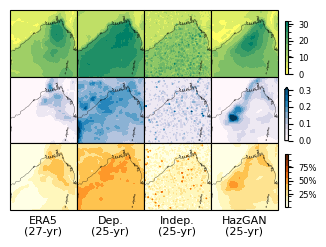

In [ ]:
from cartopy import crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import xarray as xr


plt.rcParams.update({
    'font.size': 6,
    'axes.labelsize': 7,
    'axes.titlesize': 8,
    'figure.titlesize': 8,
    'figure.titleweight': 'bold',
    'axes.titleweight': 'normal',
    'legend.fontsize': 6,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': True,
    'axes.spines.bottom': True
})

RP = 25

def damagefield(
        tree:xr.DataTree, label:str,  ds, ds_var, axs:plt.Axes, rp=10,
        add_colorbar=False, levels=10
        ) -> None:
    ds = ds.copy()
    ds["return_period"] = tree[label]['return_period']
    ds = ds.swap_dims({'sample': 'return_period'})
    ds = ds.sortby("return_period", ascending=True)
    sample = ds.sel(return_period=rp, method='nearest')
    
    # Plot on each row without colorbars
    im1 = sample.isel(field=0)[ds_var].plot.contourf(ax=axs[0], cmap="summer_r", levels=levels,
                                                     add_colorbar=False, vmin=0, vmax=32)
    im2 = sample.isel(field=1)[ds_var].plot.contourf(ax=axs[1], cmap="PuBu", levels=levels, 
                                                     add_colorbar=False, vmin=0, vmax=0.3)
    im3 = sample['damage_prob'].plot.contourf(ax=axs[2], cmap="YlOrBr", levels=levels,
                                                     add_colorbar=False, vmin=0, vmax=1)
    
    # Store the image references for later colorbar creation
    rp_approx = sample['return_period'].values.item()
    title = f"{label}\n({rp_approx:.0f}-yr)"

    if add_colorbar:
        return im1, im2, im3, title
    
    axs[0].set_title(f"{label}\n({rp_approx:.0f}-yr)", fontweight='bold')
    axs[1].set_title("")
    axs[2].set_title("")
    
    return title

# Create the figure with the appropriate layout
fig = plt.figure(figsize=(3.5, 2.6))
gs = fig.add_gridspec(3, 5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.0, hspace=0.0)

# Create axes with projections
axs = []
for row in range(3):
    row_axes = []
    for col in range(4):
        ax = fig.add_subplot(gs[row, col], projection=ccrs.PlateCarree())
        row_axes.append(ax)
    axs.append(row_axes)
axs = plt.np.array(axs)

# Create separate axes for colorbars
cbar_ax1 = fig.add_subplot(gs[0, 4])
cbar_ax2 = fig.add_subplot(gs[1, 4])
cbar_ax3 = fig.add_subplot(gs[2, 4])

# Call damagefield for the first three columns without colorbars
levels = 10
title0 = damagefield(tree, 'ERA5', train_damages, 'train', axs[:, 0], rp=RP, levels=levels)
title1 = damagefield(tree, 'Dependent', dependent_damages, 'dependent', axs[:, 1], rp=RP, levels=levels)
title2 = damagefield(tree, 'Independent', independent_damages, 'independent', axs[:, 2], rp=RP, levels=levels)

# Call the last column with colorbar flag set to True to get the image references
im1, im2, im3, title3 = damagefield(tree, 'HazGAN', fake_damages, 'fake', axs[:, 3], add_colorbar=True, rp=RP, levels=levels)

# Add colorbars using the image references from the last column
plt.colorbar(im1, cax=cbar_ax1, orientation='vertical', shrink=0.8, label='', ticks=[0, 10, 20, 30, 40], aspect=20)
plt.colorbar(im2, cax=cbar_ax2, orientation='vertical', shrink=0.8, label='', ticks=[0, 0.1, 0.2, 0.3])
plt.colorbar(im3, cax=cbar_ax3, orientation='vertical', shrink=0.8, label='', ticks=[0.25, 0.5, 0.75], format=plt.matplotlib.ticker.PercentFormatter(1, 0))
for ax in [cbar_ax1, cbar_ax2, cbar_ax3]:
    pos = ax.get_position()
    # [left, bottom, width, height] -> making them 20% thinner and 10% shorter
    ax.set_position([pos.x0 + 0.02, pos.y0 + 0.01, pos.width * 1.1, pos.height * 0.8])
    
# Set labels and features for all axes
for ax in axs.flat:
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.2)

# axs[0, 0].set_ylabel(r"Wind speed (ms$^{-1}$)")
# axs[1, 0].set_ylabel("Precipitation (m)")
# axs[2, 0].set_ylabel("Damage probability")

# Add titles to the top row
axs[-1, 0].set_title(title0, y=-.5)
axs[-1, 1].set_title(f"Dep.\n({RP}-yr)", y=-0.5)
axs[-1, 2].set_title(f"Indep.\n({RP}-yr)", y=-.5)
axs[-1, 3].set_title(f"HazGAN\n({RP}-yr)", y=-.5)

if savefigs:
    fig.savefig(
        figdir / f"{RP}yr_mangrove_damages.png",
        transparent=True,
        dpi=300,
    )

In [ ]:
def assign_rps(
        tree:xr.DataTree, label:str, ds:xr.Dataset,
        rps:list=[5, 10, 25, 50, 100]
        ) -> xr.Dataset:
    ds = ds.copy()
    ds["return_period"] = tree[label]['return_period']
    ds["expected_damage"] = tree[label]['expected_damage']
    ds = ds.swap_dims({'sample': 'return_period'})
    ds = ds.sortby("return_period", ascending=True)
    sample = ds.sel(return_period=rps, method='nearest')
    return sample

all_rps = tree['ERA5']['return_period'].values.tolist()
sample_rps = [5, 10, 25, 50, 100, 500]
train_rps = assign_rps(tree, 'ERA5', train_damages, rps=sample_rps)
gan_rps = assign_rps(tree, 'HazGAN', fake_damages, rps=sample_rps)
indep_rps = assign_rps(tree, 'Independent', independent_damages, rps=sample_rps)
dep_rps = assign_rps(tree, 'Dependent', dependent_damages, rps=sample_rps)

In [ ]:
def make_risk_profile_table(
        rps:list, train_rps:xr.Dataset, gan_rps:xr.Dataset,
        indep_rps:xr.Dataset, dep_rps:xr.Dataset,
        fraction:bool=True
        ) -> pd.DataFrame:
    
    if fraction:
        constant = mangrove_area
    else:
        constant = 1.0
    data = []
    for rp in rps:

        era5_rp = train_rps.sel(return_period=rp, method='nearest')
        data.append(['ERA5', 'Expected damage area (km²)', rp, era5_rp['expected_damage'].values.item() / constant])
        data.append(['ERA5', 'Return period (years)', rp, era5_rp['return_period'].values.item()])

        gan_rp = gan_rps.sel(return_period=rp, method='nearest')
        data.append(['HazGAN', 'Expected damage area (km²)', rp, gan_rp['expected_damage'].values.item() / constant])
        data.append(['HazGAN', 'Return period (years)', rp, gan_rp['return_period'].values.item()])

        indep_rp = indep_rps.sel(return_period=rp, method='nearest')
        data.append(['Independent', 'Expected damage area (km²)', rp, indep_rp['expected_damage'].values.item() / constant])
        data.append(['Independent', 'Return period (years)', rp, indep_rp['return_period'].values.item()])

        dep_rp = dep_rps.sel(return_period=rp, method='nearest')
        data.append(['Dependent', 'Expected damage area (km²)', rp, dep_rp['expected_damage'].values.item() / constant])
        data.append(['Dependent', 'Return period (years)', rp, dep_rp['return_period'].values.item()])
    return pd.DataFrame(data, columns=['Method', 'Deviation', 'Return Period', 'Value'])

df_risk_profile = make_risk_profile_table(
    sample_rps, train_rps, gan_rps, indep_rps, dep_rps, fraction=False
)

df_pivot = df_risk_profile.pivot_table(
    index=['Method', 'Deviation'],
    columns='Return Period',
    values='Value'
)
# Print the DataFrame
print(df_pivot.to_string(float_format='%.2f'))

InvalidIndexError: Reindexing only valid with uniquely valued Index objects

In [ ]:
gan_err = gan_rps["expected_damage"].values - train_rps["expected_damage"].values
gan_dev = gan_rps["return_period"].values - train_rps["return_period"].values
indep_err = indep_rps["expected_damage"].values - train_rps["expected_damage"].values
indep_dev = indep_rps["return_period"].values - train_rps["return_period"].values
dep_err = dep_rps["expected_damage"].values - train_rps["expected_damage"].values
dep_dev = dep_rps["return_period"].values - train_rps["return_period"].values

gan_err   = list(gan_err)
indep_err = list(indep_err)
dep_err   = list(dep_err)
gan_dev   = list(gan_dev)
indep_dev = list(indep_dev)
dep_dev   = list(dep_dev)

: 

In [ ]:
train_rps = assign_rps(tree, 'ERA5', train_damages, rps=all_rps)
gan_rps = assign_rps(tree, 'HazGAN', fake_damages, rps=all_rps)
indep_rps = assign_rps(tree, 'Independent', independent_damages, rps=all_rps)
dep_rps = assign_rps(tree, 'Dependent', dependent_damages, rps=all_rps)

def calculate_mae(ds1, ds2, var):
    """Calculate mean absolute error between two datasets."""
    return np.mean(np.abs(ds1[var].values - ds2[var].values))

mae_gan = calculate_mae(train_rps, gan_rps, 'expected_damage')
mae_indep = calculate_mae(train_rps, indep_rps, 'expected_damage')
mae_dep = calculate_mae(train_rps, dep_rps, 'expected_damage')

mae_gan_rp = calculate_mae(train_rps, gan_rps, 'return_period')
mae_indep_rp = calculate_mae(train_rps, indep_rps, 'return_period')
mae_dep_rp = calculate_mae(train_rps, dep_rps, 'return_period') 

# append the MAE errors
gan_err += [mae_gan]
indep_err += [mae_indep]
dep_err += [mae_dep]
gan_dev += [mae_gan_rp]
indep_dev += [mae_indep_rp]
dep_dev += [mae_dep_rp]
sample_rps.append('MAE')  # Add MAE to the list of return periods

: 

In [ ]:
# print the train results
print(f"Train:\n-------")
print("Expected damage area (km²) for return period 5 years:")
res5yr = train_rps.sel(return_period=5, method="nearest")["expected_damage"].values.item()
print(f"    {res5yr:.2f}, which is {res5yr/mangrove_area:.2%} of total mangrove area")
print("Expected damage area (km²) for return period 100 years:")
res100yr = train_rps.sel(return_period=100, method="nearest")["expected_damage"].values.item()
print(f"    {res100yr:.2f}, which is {res100yr/mangrove_area:.2%} of total mangrove area")

print(f"HazGAN:\n-------")
print("Expected damage area (km²) for return period 5 years:")
res5yr = gan_rps.sel(return_period=5, method="nearest")["expected_damage"].values.item()
print(f"    {res5yr:.2f}, which is {res5yr/mangrove_area:.2%} of total mangrove area")
print("Expected damage area (km²) for return period 100 years:")
res100yr = gan_rps.sel(return_period=100, method="nearest")["expected_damage"].values.item()
print(f"    {res100yr:.2f}, which is {res100yr/mangrove_area:.2%} of total mangrove area")

print(f"Independent:\n-------")
print("Expected damage area (km²) for return period 5 years:")
res5yr = indep_rps.sel(return_period=5, method="nearest")["expected_damage"].values.item()
print(f"    {res5yr:.2f}, which is {res5yr/mangrove_area:.2%} of total mangrove area")
print("Expected damage area (km²) for return period 100 years:")
res100yr = indep_rps.sel(return_period=100, method="nearest")["expected_damage"].values.item()
print(f"    {res100yr:.2f}, which is {res100yr/mangrove_area:.2%} of total mangrove area") 

print(f"Dependent:\n-------")
print("Expected damage area (km²) for return period 5 years:")
res5yr = dep_rps.sel(return_period=5, method="nearest")["expected_damage"].values.item()
print(f"    {res5yr:.2f}, which is {res5yr/mangrove_area:.2%} of total mangrove area")
print("Expected damage area (km²) for return period 100 years:")
res100yr = dep_rps.sel(return_period=100, method="nearest")["expected_damage"].values.item()
print(f"    {res100yr:.2f}, which is {res100yr/mangrove_area:.2%} of total mangrove area")

: 

In [ ]:
def make_risk_profile_table(
        rps:list, train_rps:xr.Dataset, gan_rps:xr.Dataset,
        indep_rps:xr.Dataset, dep_rps:xr.Dataset,
        fraction:bool=True
        ) -> pd.DataFrame:
    
    if fraction:
        constant = mangrove_area
    else:
        constant = 1.0
    data = []
    for rp in rps:

        # era5_rp = train_rps.sel(return_period=rp, method='nearest')
        # data.append(['ERA5', 'Expected damage area (km²)', rp, era5_rp['expected_damage'].values.item() / constant])
        # data.append(['ERA5', 'Return period (years)', rp, era5_rp['return_period'].values.item()])

        gan_rp = gan_rps.sel(return_period=rp, method='nearest')
        data.append(['HazGAN', 'Expected damage area (km²)', rp, gan_rp['expected_damage'].values.item() / constant])
        data.append(['HazGAN', 'Return period (years)', rp, gan_rp['return_period'].values.item()])

        indep_rp = indep_rps.sel(return_period=rp, method='nearest')
        data.append(['Independent', 'Expected damage area (km²)', rp, indep_rp['expected_damage'].values.item() / constant])
        data.append(['Independent', 'Return period (years)', rp, indep_rp['return_period'].values.item()])

        dep_rp = dep_rps.sel(return_period=rp, method='nearest')
        data.append(['Dependent', 'Expected damage area (km²)', rp, dep_rp['expected_damage'].values.item() / constant])
        data.append(['Dependent', 'Return period (years)', rp, dep_rp['return_period'].values.item()])
    return pd.DataFrame(data, columns=['Method', 'Deviation', 'Return Period', 'Value'])

df_risk_profile = make_risk_profile_table(
    sample_rps, train_rps, gan_rps, indep_rps, dep_rps, fraction=False
)

df_pivot = df_risk_profile.pivot_table(
    index=['Method', 'Deviation'],
    columns='Return Period',
    values='Value'
)
# Print the DataFrame
print(df_pivot.to_string(float_format='%.2f'))

Return Period                              5       10      25      50      100     500
Method      Deviation                                                                 
Dependent   Expected damage area (km²) 3173.39 3488.15 3780.44 4053.99 4311.42 4785.14
            Return period (years)         4.64   10.00   21.54   46.42  100.00  464.16
HazGAN      Expected damage area (km²) 2303.81 2482.59 2619.81 2827.21 2961.19 3301.93
            Return period (years)         4.99   10.08   24.70   49.41   98.82  494.10
Independent Expected damage area (km²) 1384.69 1437.50 1496.78 1546.22 1590.33 1660.71
            Return period (years)         5.00   10.00   25.06   50.11  100.23  513.68


In [ ]:
gan_rps

<xarray.Dataset> Size: 788kB
Dimensions:          (return_period: 6, lat: 64, lon: 64, field: 3)
Coordinates:
  * return_period    (return_period) float64 48B 4.991 10.08 ... 98.82 494.1
  * lat              (lat) float64 512B 9.994 10.23 10.47 ... 24.53 24.77 25.01
  * lon              (lon) float64 512B 79.99 80.23 80.47 ... 94.53 94.77 95.01
  * field            (field) <U4 48B 'u10' 'tp' 'mslp'
    sample           (return_period) int64 48B 262 534 192 111 60 75
Data variables:
    fake             (return_period, lat, lon, field) float64 590kB ...
    damage_prob      (return_period, lat, lon) float64 197kB ...
    rate             float64 8B 1.852
    expected_damage  (return_period) float64 48B 2.304e+03 ... 3.302e+03

In [ ]:
train_rps

<xarray.Dataset> Size: 788kB
Dimensions:          (return_period: 6, lat: 64, lon: 64, field: 3)
Coordinates:
  * return_period    (return_period) float64 48B 5.096 10.19 ... 81.54 81.54
  * lat              (lat) float64 512B 9.994 10.23 10.47 ... 24.53 24.77 25.01
  * lon              (lon) float64 512B 79.99 80.23 80.47 ... 94.53 94.77 95.01
  * field            (field) <U4 48B 'u10' 'tp' 'mslp'
    sample           (return_period) int64 48B 103 21 50 26 47 47
Data variables:
    train            (return_period, lat, lon, field) float64 590kB ...
    damage_prob      (return_period, lat, lon) float64 197kB ...
    rate             float64 8B 1.852
    expected_damage  (return_period) float64 48B 2.451e+03 ... 2.967e+03

In [ ]:
train_rps.sel(return_period=5, method='nearest')

InvalidIndexError: Reindexing only valid with uniquely valued Index objects

In [ ]:
def assign_rps(
        tree:xr.DataTree, label:str, ds:xr.Dataset,
        rps:list=[5, 10, 25, 50, 100]
        ) -> xr.Dataset:
    ds = ds.copy()
    ds["return_period"] = tree[label]['return_period']
    ds["expected_damage"] = tree[label]['expected_damage']
    ds = ds.swap_dims({'sample': 'return_period'})
    ds = ds.sortby("return_period", ascending=True)
    sample = ds.sel(return_period=rps, method='nearest')
    return sample

all_rps = tree['ERA5']['return_period'].values.tolist()
sample_rps = [5, 10, 25, 50, 100, 500]
train_rps = assign_rps(tree, 'ERA5', train_damages, rps=sample_rps)
gan_rps = assign_rps(tree, 'HazGAN', fake_damages, rps=sample_rps)
indep_rps = assign_rps(tree, 'Independent', independent_damages, rps=sample_rps)
dep_rps = assign_rps(tree, 'Dependent', dependent_damages, rps=sample_rps)

In [ ]:
train_rps.sel(return_period=5)

KeyError: "not all values found in index 'return_period'. Try setting the `method` keyword argument (example: method='nearest')."

In [ ]:
gan_rps.sel(return_period=5, method="nearest")

<xarray.Dataset> Size: 132kB
Dimensions:          (lat: 64, lon: 64, field: 3)
Coordinates:
  * lat              (lat) float64 512B 9.994 10.23 10.47 ... 24.53 24.77 25.01
  * lon              (lon) float64 512B 79.99 80.23 80.47 ... 94.53 94.77 95.01
  * field            (field) <U4 48B 'u10' 'tp' 'mslp'
    sample           int64 8B 262
    return_period    float64 8B 4.991
Data variables:
    fake             (lat, lon, field) float64 98kB ...
    damage_prob      (lat, lon) float64 33kB ...
    rate             float64 8B 1.852
    expected_damage  float64 8B 2.304e+03